# LSEG vs Bloomberg: S&P 500 Dividend Futures Price Validation

Compare daily pricing for SDA (S&P 500 Annual Dividend) futures downloaded from LSEG Datastream against Bloomberg data to validate correctness.

**BBG files**: `asdz3.csv` through `asdz9.csv` (Dec 2023 – Dec 2029)  
**LSEG file**: `futures_daily_prices.csv` (composite `SDAZ*` and electronic `01SDAZ*`)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Resolve paths relative to this notebook's location
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("validate_lseg_vs_bbg.ipynb"))
# If running from Jupyter, use a more reliable approach
if not os.path.exists(os.path.join(NOTEBOOK_DIR, "asdz3.csv")):
    # Try common locations
    for candidate in [os.getcwd(), os.path.expanduser("~/wrds-data/bbg")]:
        if os.path.exists(os.path.join(candidate, "asdz3.csv")):
            NOTEBOOK_DIR = candidate
            break

BBG_DIR = NOTEBOOK_DIR
LSEG_DIR = os.path.join(os.path.dirname(NOTEBOOK_DIR), "LSEG datastream")

print(f"BBG dir: {BBG_DIR}")
print(f"LSEG dir: {LSEG_DIR}")

# BBG ticker -> LSEG RIC mapping
# BBG uses single-digit year, LSEG uses ^2 suffix for 2020s expired, ^1 for 2010s
bbg_to_lseg = {
    "asdz3": "SDAZ3^2",    # Dec 2023 (expired)
    "asdz4": "SDAZ24^2",   # Dec 2024 (expired)
    "asdz5": "SDAZ25^2",   # Dec 2025 (expired)
    "asdz6": "SDAZ26",     # Dec 2026
    "asdz7": "SDAZ27",     # Dec 2027
    "asdz8": "SDAZ28",     # Dec 2028
    "asdz9": "SDAZ29",     # Dec 2029
}

# Load LSEG data
lseg = pd.read_csv(os.path.join(LSEG_DIR, "futures_daily_prices.csv"), parse_dates=["date"])
lseg_sda = lseg[lseg["product"] == "SDA"].copy()
print(f"LSEG SDA futures: {lseg_sda['RIC'].nunique()} RICs, {len(lseg_sda)} rows")
print(f"Available RICs: {sorted(lseg_sda['RIC'].unique())}")

BBG dir: /home/rakin/wrds-data/bbg
LSEG dir: /home/rakin/wrds-data/LSEG datastream
LSEG SDA futures: 27 RICs, 42857 rows
Available RICs: ['01SDAZ0^2', '01SDAZ1^2', '01SDAZ24^2', '01SDAZ25^2', '01SDAZ2^2', '01SDAZ3^2', '01SDAZ5^1', '01SDAZ6^1', '01SDAZ7^1', '01SDAZ8^1', '01SDAZ9^1', 'SDAZ1^2', 'SDAZ24^2', 'SDAZ25^2', 'SDAZ26', 'SDAZ27', 'SDAZ28', 'SDAZ29', 'SDAZ2^2', 'SDAZ30', 'SDAZ31', 'SDAZ32', 'SDAZ33', 'SDAZ34', 'SDAZ35', 'SDAZ36', 'SDAZ3^2']


In [4]:
# Load all BBG files and merge with LSEG on date
comparisons = {}

for bbg_ticker, lseg_ric in bbg_to_lseg.items():
    # Load BBG — auto-detect delimiter (asdz7 is tab-delimited, rest are comma)
    bbg_df = pd.read_csv(os.path.join(BBG_DIR, f"{bbg_ticker}.csv"), sep=None, engine="python", parse_dates=["Date"])
    bbg_df = bbg_df.rename(columns={"Date": "date", "Last Price": "bbg_price", "Open Interest": "bbg_oi"})
    bbg_df = bbg_df[["date", "bbg_price", "bbg_oi"]].dropna(subset=["bbg_price"])
    
    # Get LSEG data for this RIC
    lseg_ric_df = lseg_sda[lseg_sda["RIC"] == lseg_ric][["date", "TRDPRC_1", "SETTLE", "OPINT_1"]].copy()
    lseg_ric_df = lseg_ric_df.rename(columns={"TRDPRC_1": "lseg_last", "SETTLE": "lseg_settle", "OPINT_1": "lseg_oi"})
    
    if lseg_ric_df.empty:
        print(f"{bbg_ticker} -> {lseg_ric}: NO LSEG DATA")
        continue
    
    # Merge on date
    merged = pd.merge(bbg_df, lseg_ric_df, on="date", how="inner")
    comparisons[bbg_ticker] = {
        "ric": lseg_ric,
        "merged": merged,
        "bbg_rows": len(bbg_df),
        "lseg_rows": len(lseg_ric_df),
        "matched_rows": len(merged),
    }
    
    print(f"{bbg_ticker} -> {lseg_ric}: BBG={len(bbg_df)} rows, LSEG={len(lseg_ric_df)} rows, matched={len(merged)} rows")

asdz3 -> SDAZ3^2: BBG=1517 rows, LSEG=1714 rows, matched=1517 rows
asdz4 -> SDAZ24^2: BBG=1767 rows, LSEG=2294 rows, matched=1767 rows
asdz5 -> SDAZ25^2: BBG=1771 rows, LSEG=2133 rows, matched=1771 rows
asdz6 -> SDAZ26: BBG=1725 rows, LSEG=2133 rows, matched=1725 rows
asdz7 -> SDAZ27: BBG=2029 rows, LSEG=2133 rows, matched=2029 rows
asdz8 -> SDAZ28: BBG=2029 rows, LSEG=2133 rows, matched=2029 rows
asdz9 -> SDAZ29: BBG=1816 rows, LSEG=2133 rows, matched=1816 rows


## Price Comparison: BBG Last Price vs LSEG Last / Settle

For each contract, compare BBG "Last Price" against both LSEG `TRDPRC_1` (last trade) and `SETTLE` (settlement). Compute difference stats.

In [5]:
# Summary stats for each contract
summary_rows = []

for ticker, info in comparisons.items():
    m = info["merged"]
    
    # Diff vs LSEG last trade
    diff_last = m["bbg_price"] - m["lseg_last"]
    # Diff vs LSEG settle
    diff_settle = m["bbg_price"] - m["lseg_settle"]
    
    # Exact match rates
    exact_last = (diff_last.abs() < 0.005).mean()
    exact_settle = (diff_settle.abs() < 0.005).mean()
    close_last = (diff_last.abs() < 0.10).mean()
    close_settle = (diff_settle.abs() < 0.10).mean()
    
    summary_rows.append({
        "contract": ticker,
        "ric": info["ric"],
        "n_matched": info["matched_rows"],
        "vs_last_mean_diff": diff_last.mean(),
        "vs_last_median_diff": diff_last.median(),
        "vs_last_max_abs_diff": diff_last.abs().max(),
        "vs_last_exact_pct": exact_last,
        "vs_last_close_pct": close_last,
        "vs_settle_mean_diff": diff_settle.mean(),
        "vs_settle_median_diff": diff_settle.median(),
        "vs_settle_max_abs_diff": diff_settle.abs().max(),
        "vs_settle_exact_pct": exact_settle,
        "vs_settle_close_pct": close_settle,
    })

summary = pd.DataFrame(summary_rows)
summary.round(4)

,contract,ric,n_matched,vs_last_mean_diff,vs_last_median_diff,vs_last_max_abs_diff,vs_last_exact_pct,vs_last_close_pct,vs_settle_mean_diff,vs_settle_median_diff,vs_settle_max_abs_diff,vs_settle_exact_pct,vs_settle_close_pct
0,asdz3,SDAZ3^2,1517,-0.0199,0.0,3.35,0.2076,0.4186,0.0,0.0,0.00,1.0000,1.0000
1,asdz4,SDAZ24^2,1767,-0.0252,0.0,5.35,0.1573,0.4120,0.0,0.0,0.00,1.0000,1.0000
2,asdz5,SDAZ25^2,1771,-0.0136,0.0,3.20,0.1491,0.4054,0.0,0.0,0.00,0.9994,0.9994
3,asdz6,SDAZ26,1725,0.0009,0.0,3.75,0.1438,0.3704,-0.0,0.0,0.05,0.9988,0.9994
4,asdz7,SDAZ27,2029,-0.0075,0.0,5.15,0.1474,0.3021,0.0,0.0,0.00,0.9995,0.9995
5,asdz8,SDAZ28,2029,0.0048,0.0,4.45,0.1503,0.2499,-0.0,0.0,0.05,0.9990,0.9995
6,asdz9,SDAZ29,1816,-0.0162,0.0,5.65,0.1531,0.2148,-0.0,0.0,0.05,0.9989,0.9994


## Time Series Plots

Overlay BBG and LSEG price series for each contract to visually inspect alignment.

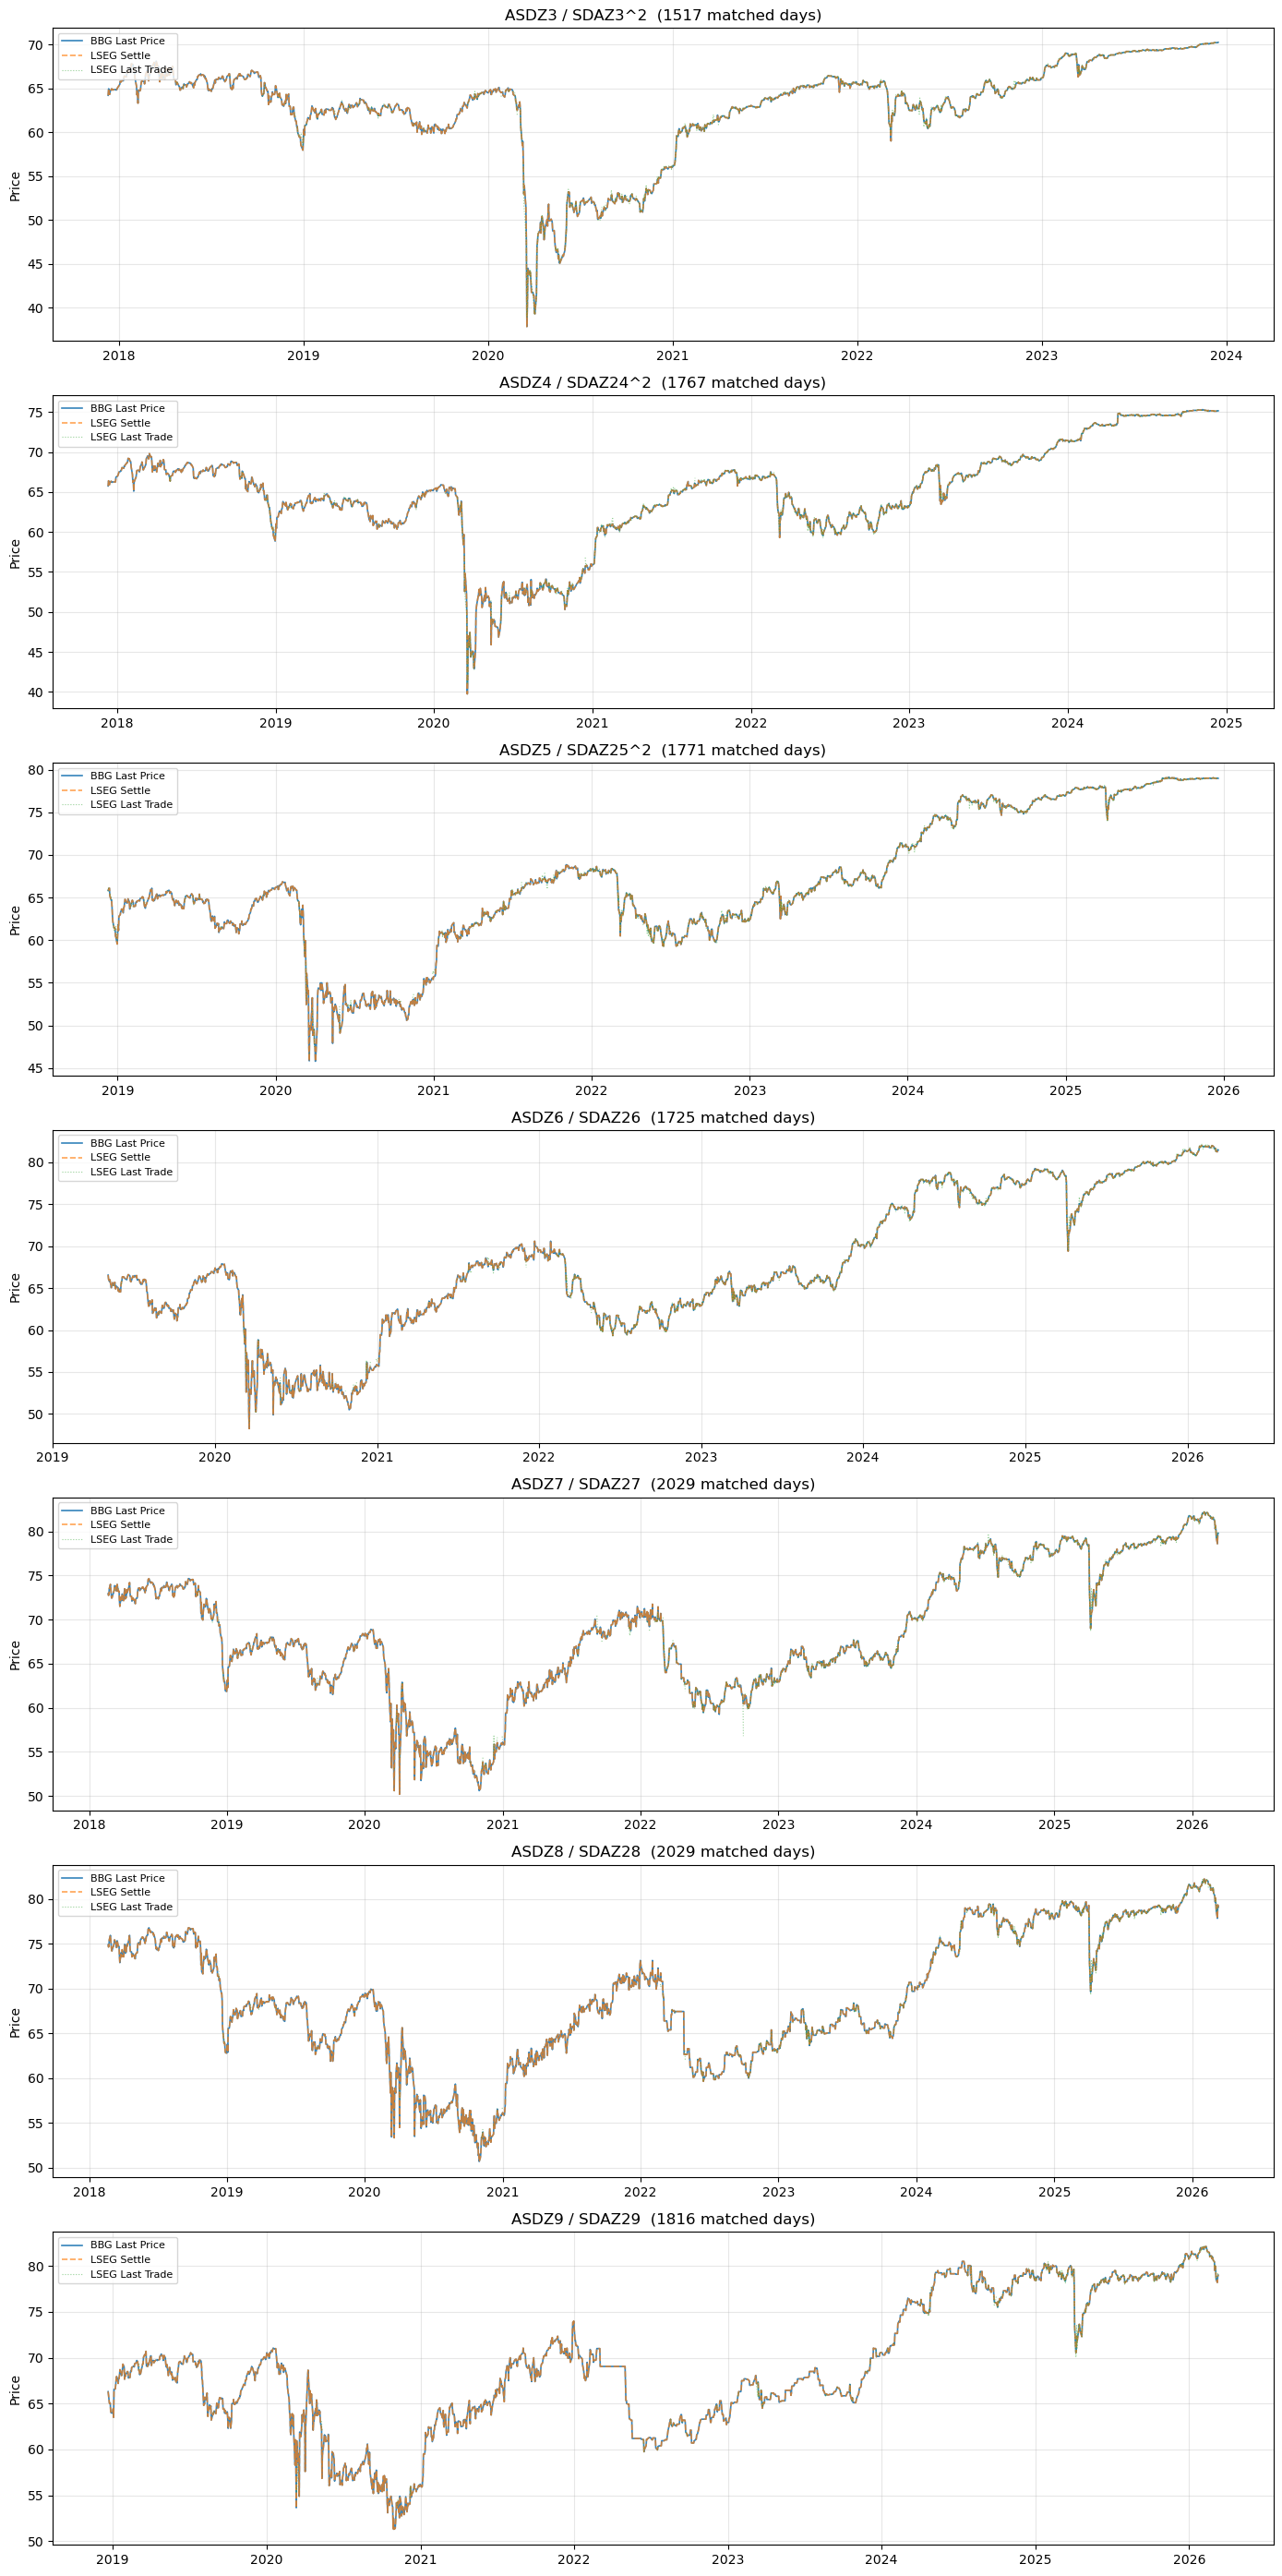

In [6]:
fig, axes = plt.subplots(len(comparisons), 1, figsize=(14, 4 * len(comparisons)), sharex=False)
if len(comparisons) == 1:
    axes = [axes]

for ax, (ticker, info) in zip(axes, comparisons.items()):
    m = info["merged"].sort_values("date")
    
    ax.plot(m["date"], m["bbg_price"], label="BBG Last Price", linewidth=1.2, alpha=0.9)
    ax.plot(m["date"], m["lseg_settle"], label="LSEG Settle", linewidth=1.2, alpha=0.7, linestyle="--")
    ax.plot(m["date"], m["lseg_last"], label="LSEG Last Trade", linewidth=0.8, alpha=0.5, linestyle=":")
    
    ax.set_title(f"{ticker.upper()} / {info['ric']}  ({info['matched_rows']} matched days)")
    ax.set_ylabel("Price")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Price Difference Distribution

Histogram of daily price differences (BBG - LSEG) to check for systematic bias.

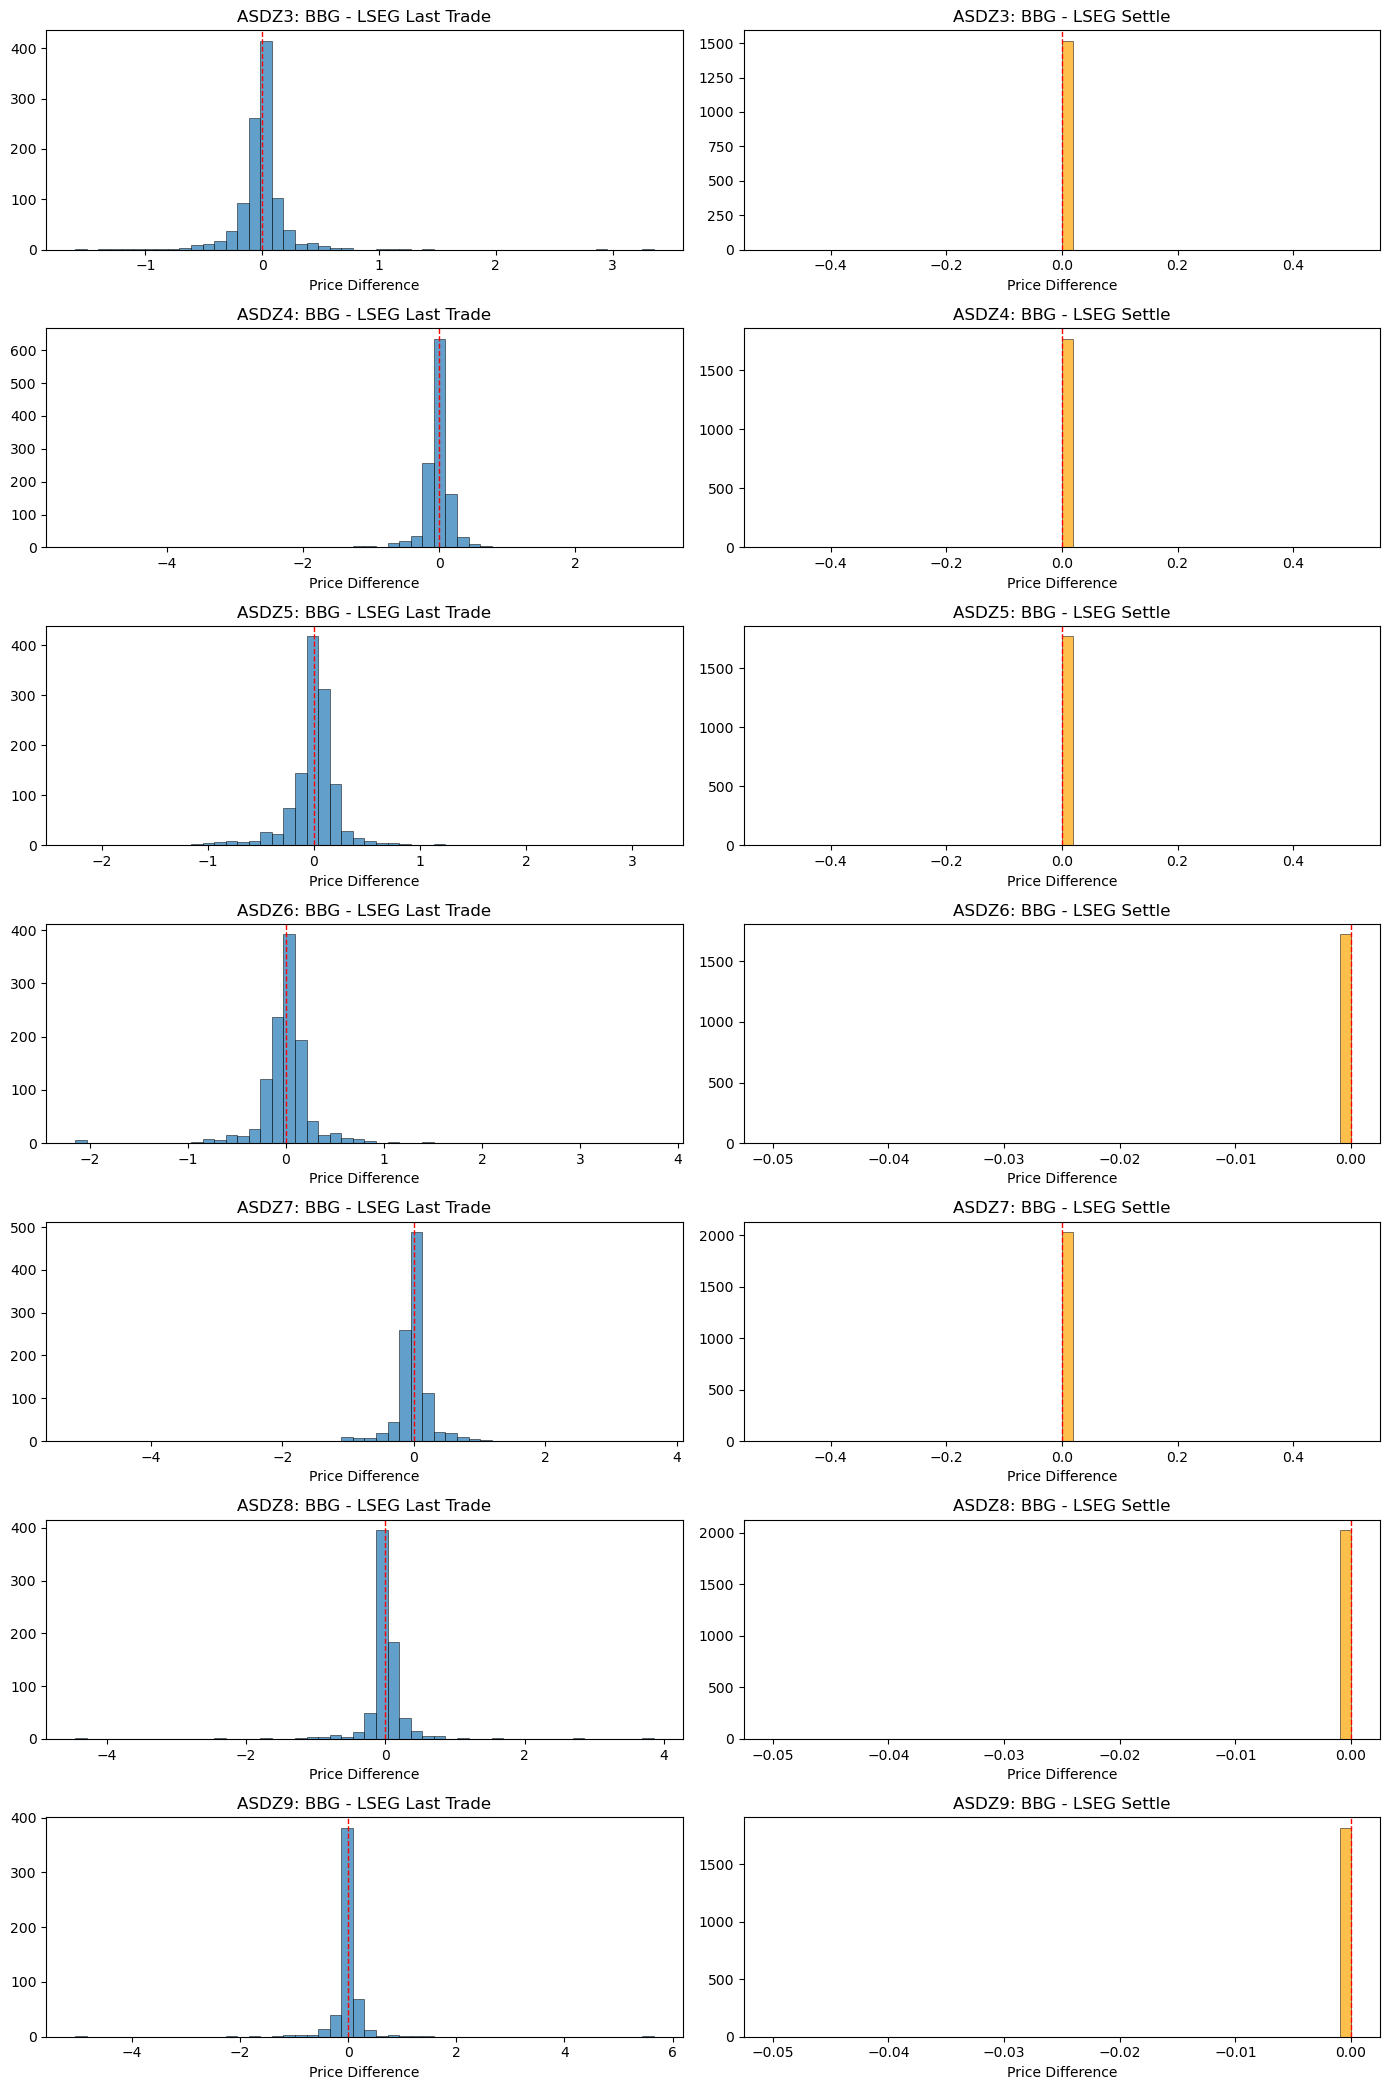

In [7]:
fig, axes = plt.subplots(len(comparisons), 2, figsize=(14, 3 * len(comparisons)))
if len(comparisons) == 1:
    axes = axes.reshape(1, -1)

for i, (ticker, info) in enumerate(comparisons.items()):
    m = info["merged"]
    
    diff_last = m["bbg_price"] - m["lseg_last"]
    diff_settle = m["bbg_price"] - m["lseg_settle"]
    
    axes[i, 0].hist(diff_last.dropna(), bins=50, alpha=0.7, edgecolor="black", linewidth=0.5)
    axes[i, 0].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i, 0].set_title(f"{ticker.upper()}: BBG - LSEG Last Trade")
    axes[i, 0].set_xlabel("Price Difference")
    
    axes[i, 1].hist(diff_settle.dropna(), bins=50, alpha=0.7, color="orange", edgecolor="black", linewidth=0.5)
    axes[i, 1].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i, 1].set_title(f"{ticker.upper()}: BBG - LSEG Settle")
    axes[i, 1].set_xlabel("Price Difference")

plt.tight_layout()
plt.show()

## Open Interest Comparison

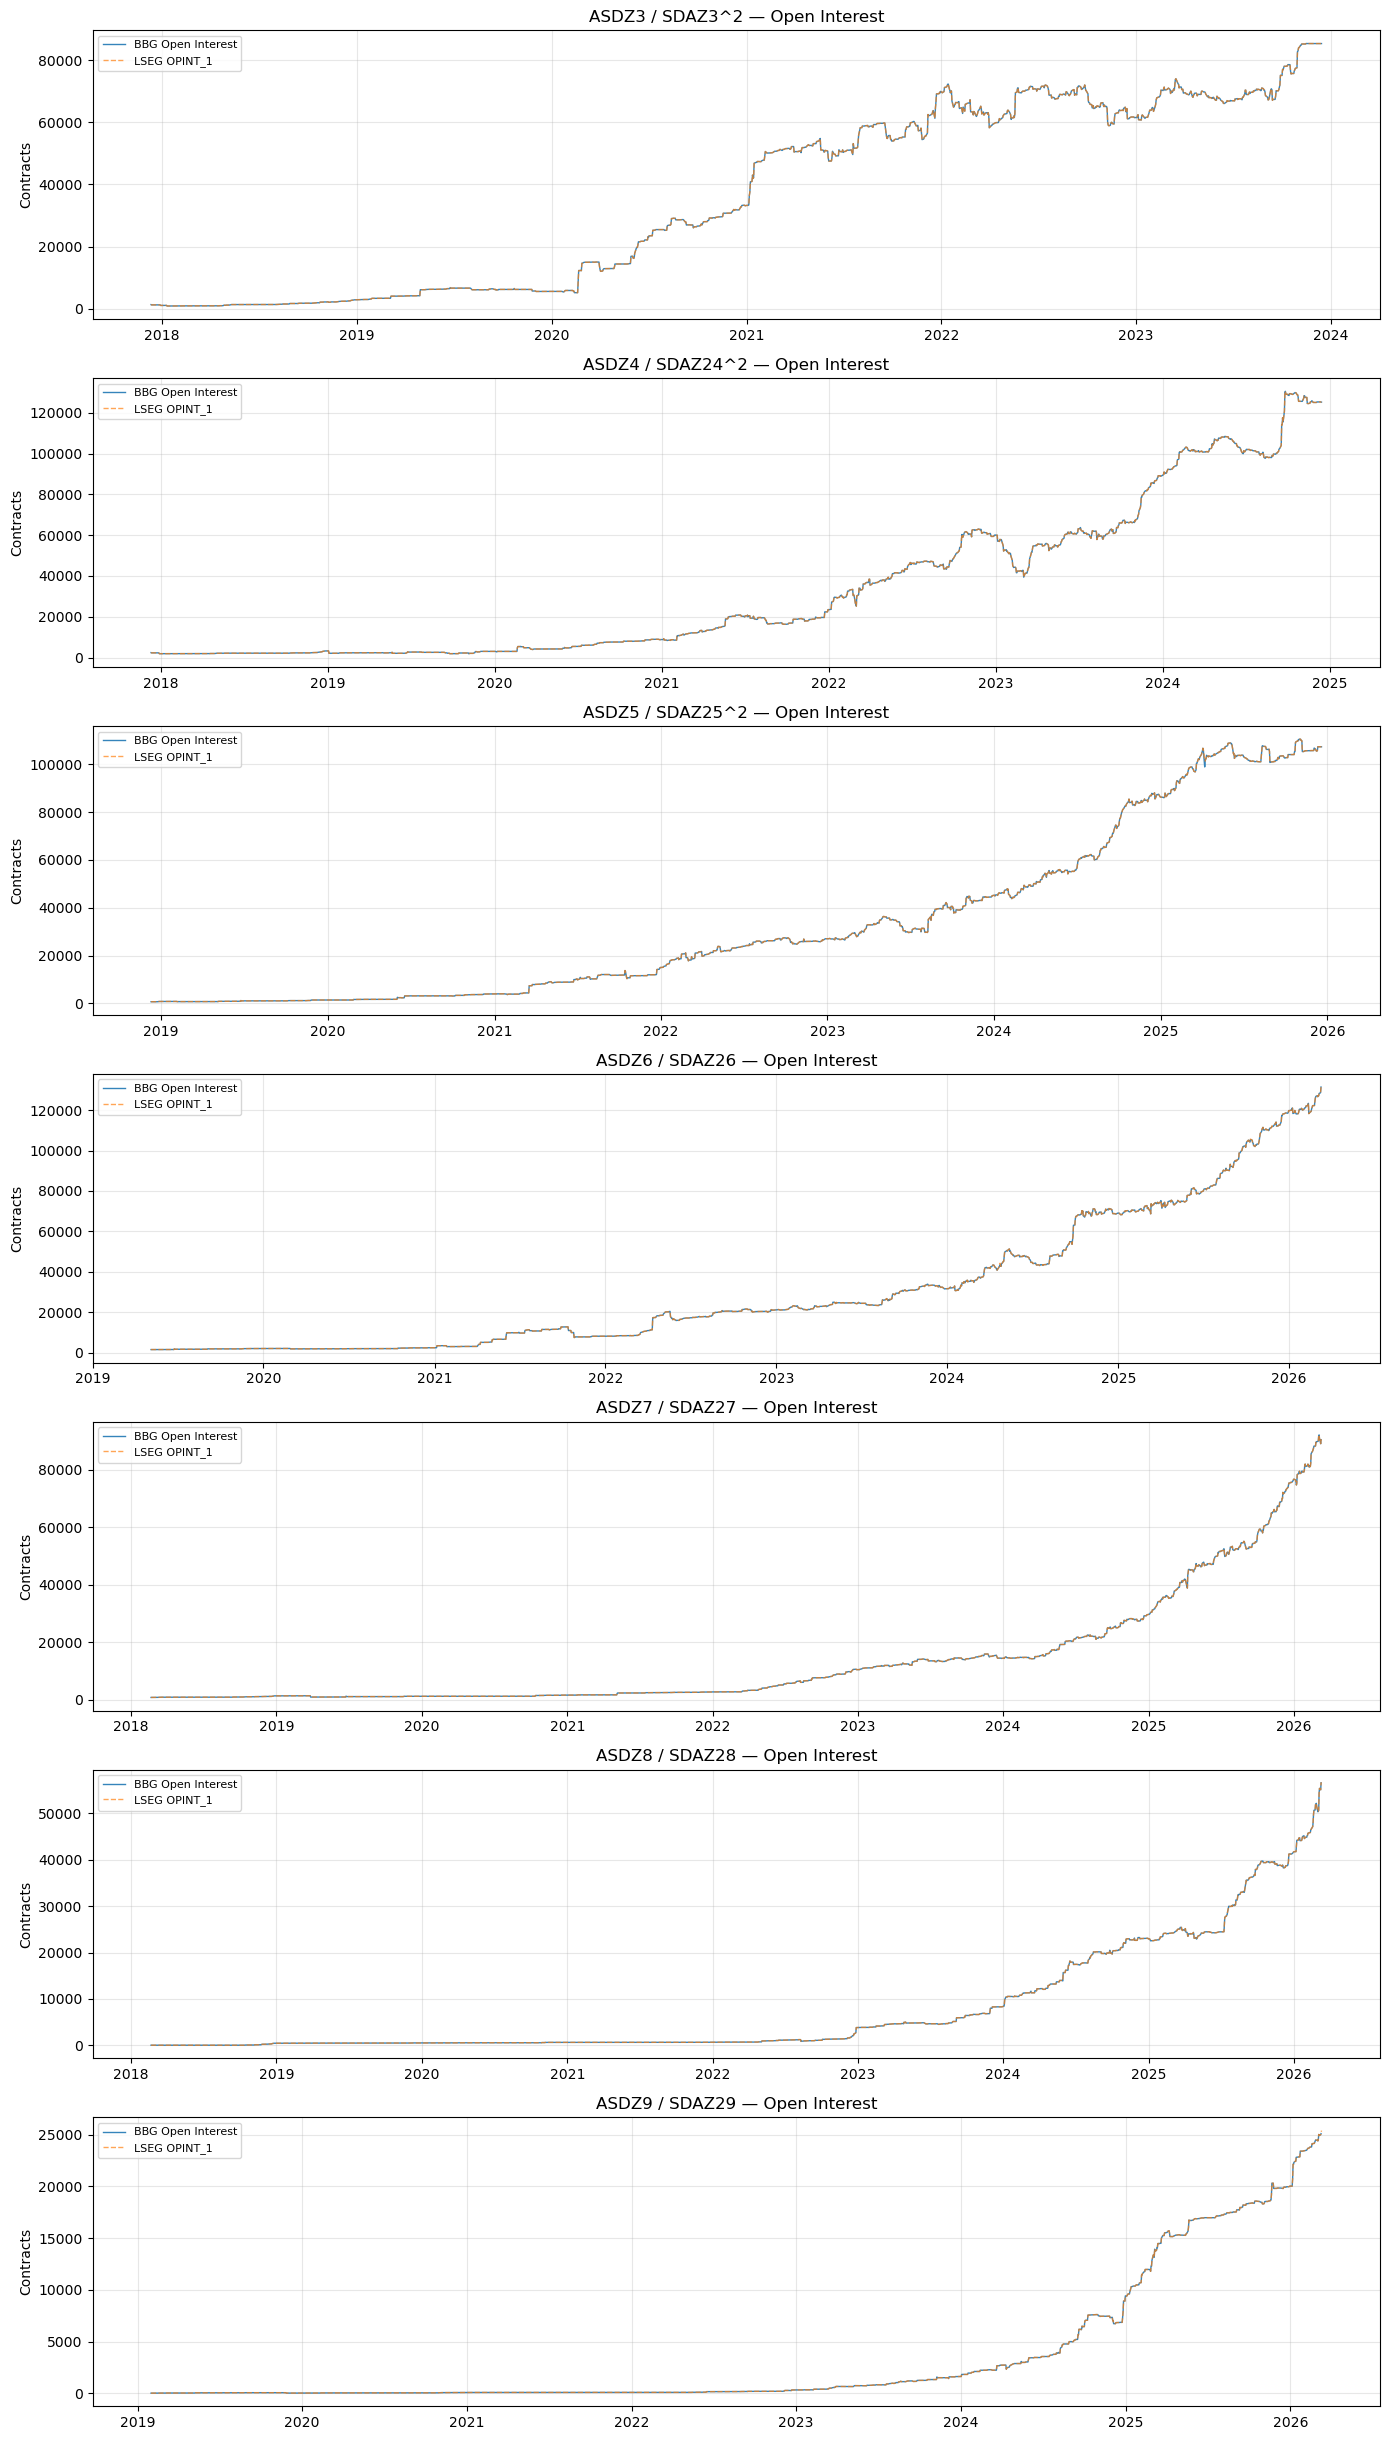

In [8]:
fig, axes = plt.subplots(len(comparisons), 1, figsize=(14, 3.5 * len(comparisons)))
if len(comparisons) == 1:
    axes = [axes]

for ax, (ticker, info) in zip(axes, comparisons.items()):
    m = info["merged"].sort_values("date")
    
    ax.plot(m["date"], m["bbg_oi"], label="BBG Open Interest", linewidth=1, alpha=0.9)
    ax.plot(m["date"], m["lseg_oi"], label="LSEG OPINT_1", linewidth=1, alpha=0.7, linestyle="--")
    
    ax.set_title(f"{ticker.upper()} / {info['ric']} — Open Interest")
    ax.set_ylabel("Contracts")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Days with Large Discrepancies

Show dates where BBG and LSEG prices differ by more than $0.50 — these may indicate different price types (last vs settle) or data issues.

In [9]:
threshold = 0.50

for ticker, info in comparisons.items():
    m = info["merged"].copy()
    m["diff_last"] = m["bbg_price"] - m["lseg_last"]
    m["diff_settle"] = m["bbg_price"] - m["lseg_settle"]
    
    # Flag where both LSEG fields diverge from BBG
    outliers = m[(m["diff_last"].abs() > threshold) & (m["diff_settle"].abs() > threshold)]
    
    if len(outliers) > 0:
        print(f"\n{ticker.upper()} / {info['ric']}: {len(outliers)} days with |diff| > ${threshold}")
        print(outliers[["date", "bbg_price", "lseg_last", "lseg_settle", "diff_last", "diff_settle"]].to_string(index=False))
    else:
        print(f"{ticker.upper()} / {info['ric']}: No large discrepancies (all within ${threshold})")

ASDZ3 / SDAZ3^2: No large discrepancies (all within $0.5)
ASDZ4 / SDAZ24^2: No large discrepancies (all within $0.5)
ASDZ5 / SDAZ25^2: No large discrepancies (all within $0.5)
ASDZ6 / SDAZ26: No large discrepancies (all within $0.5)
ASDZ7 / SDAZ27: No large discrepancies (all within $0.5)
ASDZ8 / SDAZ28: No large discrepancies (all within $0.5)
ASDZ9 / SDAZ29: No large discrepancies (all within $0.5)


## Correlation Matrix

Pearson correlation between BBG price, LSEG last trade, and LSEG settle across all contracts pooled.

In [10]:
# Pool all matched data and compute correlations
all_merged = pd.concat([info["merged"] for info in comparisons.values()], ignore_index=True)

corr_cols = ["bbg_price", "lseg_last", "lseg_settle"]
print(f"Total matched observations: {len(all_merged)}")
print(f"\nCorrelation matrix:")
print(all_merged[corr_cols].corr().round(6))

print(f"\nOI correlation:")
print(all_merged[["bbg_oi", "lseg_oi"]].corr().round(6))

Total matched observations: 12654

Correlation matrix:
             bbg_price  lseg_last  lseg_settle
bbg_price     1.000000   0.999235     1.000000
lseg_last     0.999235   1.000000     0.999235
lseg_settle   1.000000   0.999235     1.000000

OI correlation:
           bbg_oi   lseg_oi
bbg_oi   1.000000  0.999999
lseg_oi  0.999999  1.000000
